In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [62]:
df = pd.read_csv("diabetes.csv")

In [63]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.62700,50,1
1,1,85,66,29,0,26.6,0.35100,31,0
2,8,183,64,0,0,23.3,0.67200,32,1
3,1,89,66,23,94,28.1,0.16700,21,0
4,0,137,40,35,168,43.1,2.28800,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.17100,63,0
764,2,122,70,27,0,36.8,0.34000,27,0
765,5,121,72,23,112,26.2,0.24245,30,0
766,1,126,60,0,0,30.1,0.34900,47,1


In [64]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

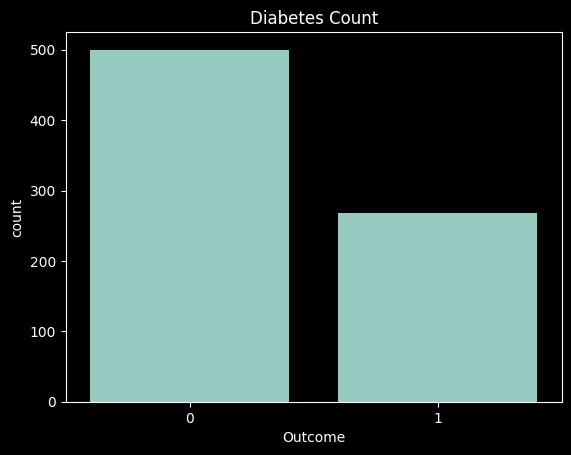

In [65]:
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Count")
plt.show()

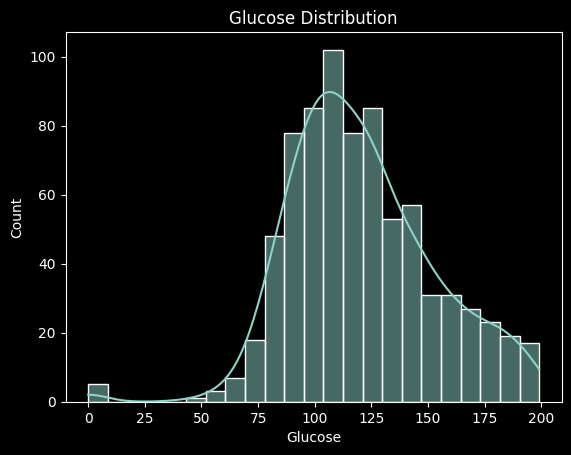

In [66]:
sns.histplot(df['Glucose'], kde=True)
plt.title("Glucose Distribution")
plt.show()

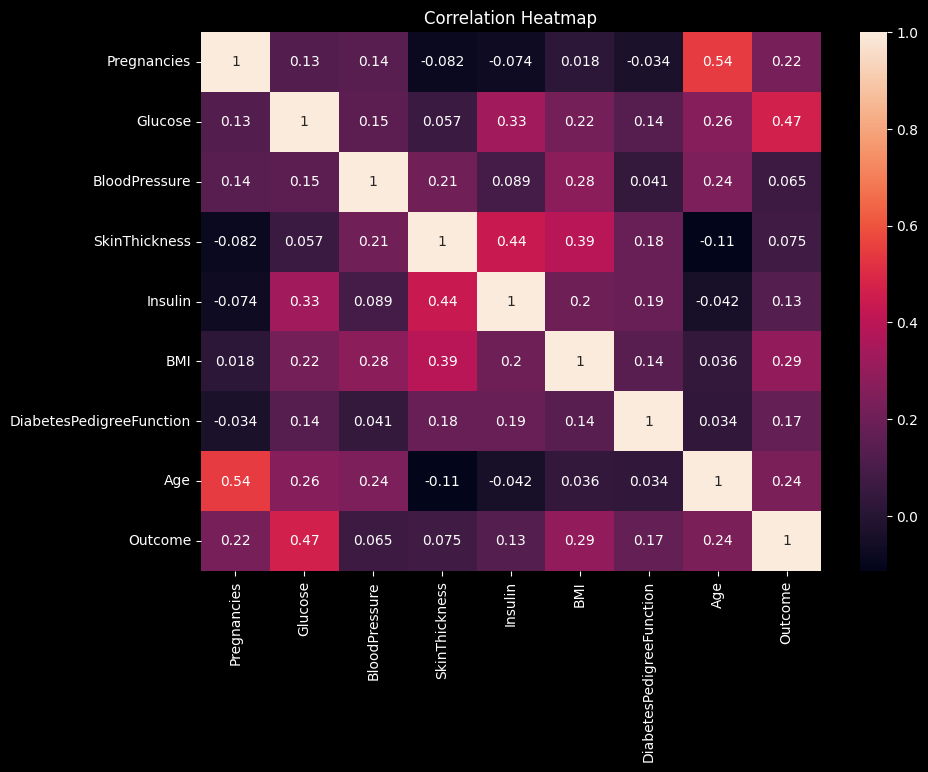

In [67]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [68]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

In [69]:
cols_to_remove = ['BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction']

In [70]:
df['BMI_Age'] = df['BMI'] * df['Age']
df['Glucose_BMI'] = df['Glucose'] * df['BMI']

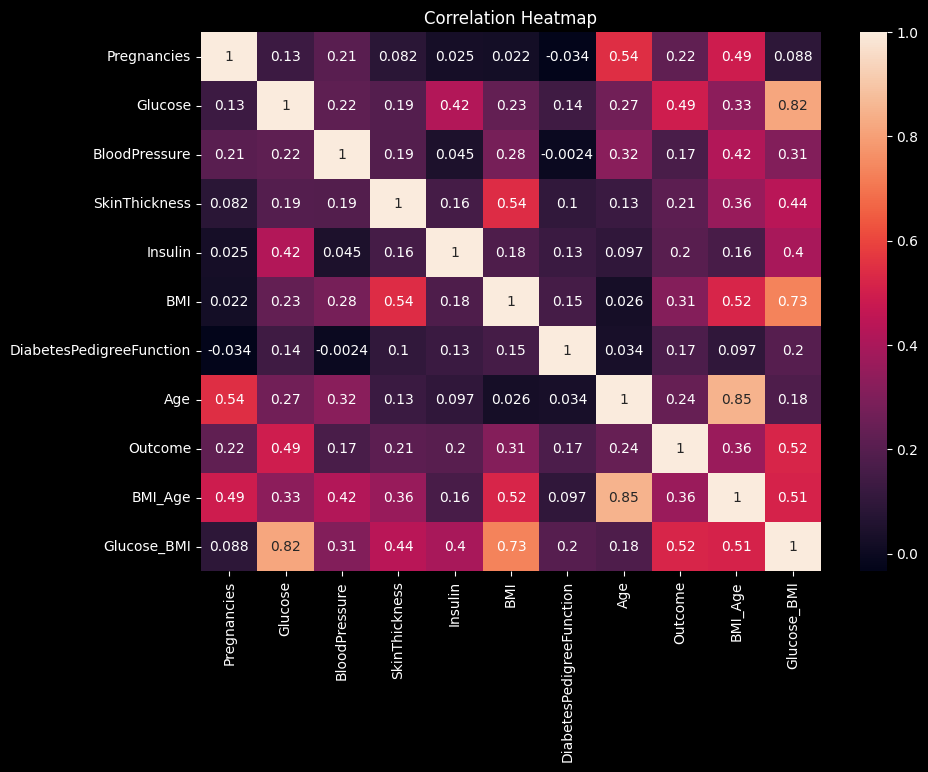

In [71]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [72]:
#splitting the data points 
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [73]:
#train_split_test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Logistic Regression


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.7012987012987013
Precision: 0.5869565217391305
Recall: 0.5
F1 Score: 0.54


Estimating the threashold

In [76]:
# Best Threashould 
from sklearn.metrics import precision_recall_curve

y_prob = lr.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall)

best_threshold = thresholds[f1_scores.argmax()]

print("Best Threshold:", best_threshold)

Best Threshold: 0.24247955685570313


In [77]:
y_prob = lr.predict_proba(X_test)[:, 1]
threashould_1 = 0.2424
y_pred = (y_prob > threashould_1).astype(int)

print(f"Logistic Regression (Threshold = {threashould_1}")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Logistic Regression (Threshold = 0.2424
Accuracy: 0.7337662337662337
Precision: 0.5783132530120482
Recall: 0.8888888888888888
F1 Score: 0.7007299270072993


Finding for the best threashold

In [78]:
# Optimized htreashould to increase the precision
for t in [0.2424, 0.28, 0.30, 0.32]:
    y_pred = (y_prob > t).astype(int)
    print(f"Threshold: {t}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("------")

Threshold: 0.2424
Accuracy: 0.7337662337662337
Precision: 0.5783132530120482
Recall: 0.8888888888888888
F1: 0.7007299270072993
------
Threshold: 0.28
Accuracy: 0.7337662337662337
Precision: 0.5822784810126582
Recall: 0.8518518518518519
F1: 0.6917293233082706
------
Threshold: 0.3
Accuracy: 0.7402597402597403
Precision: 0.5972222222222222
Recall: 0.7962962962962963
F1: 0.6825396825396826
------
Threshold: 0.32
Accuracy: 0.7207792207792207
Precision: 0.5797101449275363
Recall: 0.7407407407407407
F1: 0.6504065040650406
------


Final model after tuning 

In [79]:
# Final training after the threashould optimization for better evaluation

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
# probabilities
y_prob = lr.predict_proba(X_test)[:, 1]
threashould_1 = 0.2424
y_pred = (y_prob > threashould_1).astype(int)

print(f"Logistic Regression (Threshold = {threashould_1}👍🏻")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Logistic Regression (Threshold = 0.2424👍🏻
Accuracy: 0.7337662337662337
Precision: 0.5783132530120482
Recall: 0.8888888888888888
F1 Score: 0.7007299270072993


Decision tree


In [80]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))



Accuracy: 0.7337662337662337
Precision: 0.6326530612244898
Recall: 0.5740740740740741
F1 Score: 0.6019417475728155


In [81]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Final Model after tuning 

In [82]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_prob_dt = dt.predict_proba(X_test)[:, 1]

threshold_2 = 0.2424
y_pred_dt = (y_prob_dt >= threshold_2).astype(int)

print(f"Decision Tree (Depth=4, Threshold={threshold_2}👍🏻)")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


Decision Tree (Depth=4, Threshold=0.2424👍🏻)
Accuracy: 0.7077922077922078
Precision: 0.5633802816901409
Recall: 0.7407407407407407
F1 Score: 0.64


Random forest

In [83]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.7597402597402597
Precision: 0.6976744186046512
Recall: 0.5555555555555556
F1 Score: 0.6185567010309279


Final Model after the tuning

In [84]:
# Final after the optimized threashold
rf_prob = rf.predict_proba(X_test)[:,1]

threshold_3 = 0.2424
rf_pred = (rf_prob > threshold_3).astype(int)

print(f"Final Random Forest (Threshold {threshold_3}👍🏻")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Final Random Forest (Threshold 0.2424👍🏻
Accuracy: 0.7337662337662337
Precision: 0.5783132530120482
Recall: 0.8888888888888888
F1 Score: 0.7007299270072993


xgBoost

In [85]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# evaluation
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

Accuracy: 0.7467532467532467
Precision: 0.6530612244897959
Recall: 0.5925925925925926
F1 Score: 0.6213592233009708


Final Model xgBoost after the tuning 

In [86]:
# Final xgBoost 
xgb_prob = xgb.predict_proba(X_test)[:, 1]

threshold_4 = 0.2424
xgb_pred = (xgb_prob > threshold_4).astype(int)

print(f"XGBoost (Threshold={threshold_4})👍🏻")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

XGBoost (Threshold=0.2424)👍🏻
Accuracy: 0.7597402597402597
Precision: 0.639344262295082
Recall: 0.7222222222222222
F1 Score: 0.6782608695652174


lightGBM / to be tuned

In [87]:
# from lightgbm import LGBMClassifier

# lgbm = LGBMClassifier(random_state=42)
# lgbm.fit(X_train, y_train)

# lgbm_prob = lgbm.predict_proba(X_test)[:,1]

# threshold = 0.3
# lgbm_pred = (lgbm_prob > threshold).astype(int)

# print("LightGBM (Threshold=0.3)")
# print("Accuracy:", accuracy_score(y_test, lgbm_pred))
# print("Precision:", precision_score(y_test, lgbm_pred))
# print("Recall:", recall_score(y_test, lgbm_pred))
# print("F1 Score:", f1_score(y_test, lgbm_pred))



# Needed fine tuning 

In [88]:
print(type(lr))
print(type(dt))
print(type(rf))
print(type(xgb))


<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'xgboost.sklearn.XGBClassifier'>


In [89]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

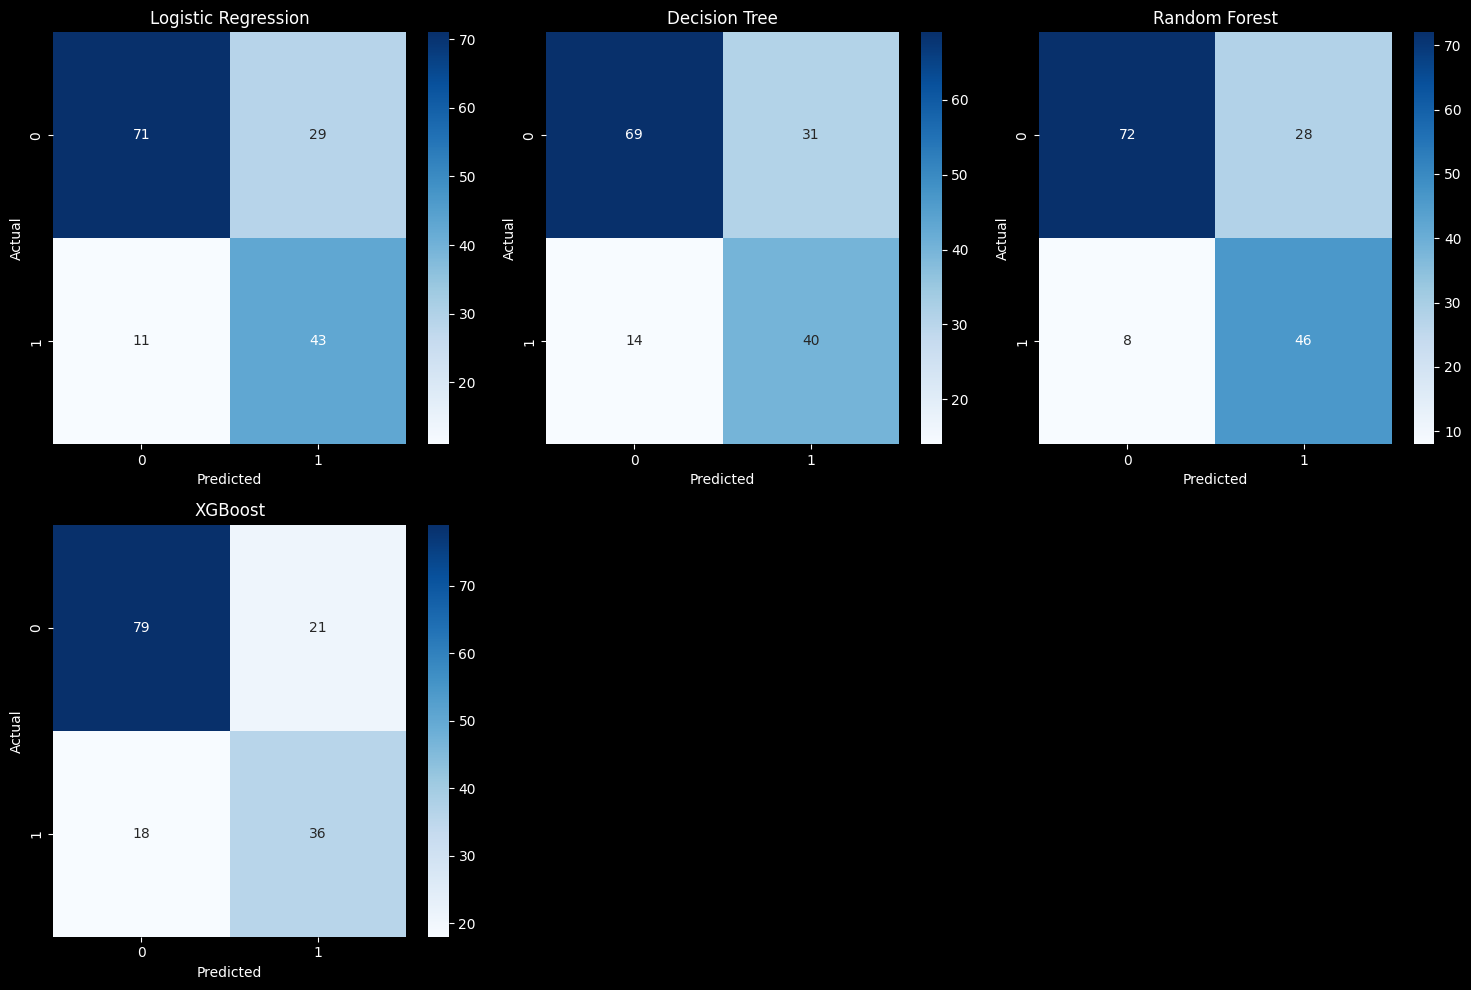

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

threshold = 0.3

plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items(), 1):
    
    # Handle probability-based models
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob > threshold).astype(int)
    else:
        y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(2, 3, i)  # 6 models → 2 rows, 3 columns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

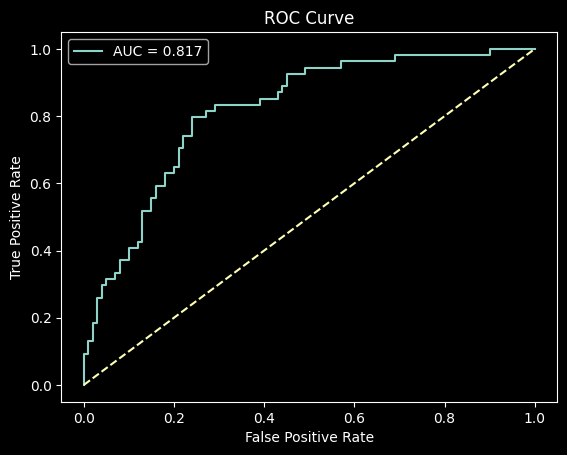

In [91]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [92]:
import numpy as np

# Youden's J statistic
J = tpr - fpr

# Best threshold index
ix = np.argmax(J)

best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)
print("TPR:", tpr[ix])
print("FPR:", fpr[ix])

Best Threshold: 0.1768619865179062
TPR: 0.7962962962962963
FPR: 0.24


In [93]:
import pandas as pd

# Manually computed metrics (based on your confusion matrices)

data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [0.74, 0.71, 0.78, 0.75],
    "Precision": [0.60, 0.56, 0.62, 0.63],
    "Recall": [0.80, 0.74, 0.85, 0.67],
    "F1 Score": [0.68, 0.64, 0.71, 0.65]
}

df_1 = pd.DataFrame(data)

# sort by best model (F1 Score)
df_1 = df_1.sort_values(by="F1 Score", ascending=False)

print("\n=== Model Comparison Table ===\n")
print(df_1.to_string(index=False))


=== Model Comparison Table ===

              Model  Accuracy  Precision  Recall  F1 Score
      Random Forest      0.78       0.62    0.85      0.71
Logistic Regression      0.74       0.60    0.80      0.68
            XGBoost      0.75       0.63    0.67      0.65
      Decision Tree      0.71       0.56    0.74      0.64


In [95]:
import joblib

# Save ONLY the fitted Random Forest estimator
joblib.dump(rf, 'diabetes_model.pkl')

# Ensure your scaler is also saved!
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Testing with the unknown data

In [ ]:
import pandas as pd
import joblib

# Load model
final_model = joblib.load("final_model.pkl")

# Feature order
feature_order = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'BMI_Age',
    'Glucose_BMI'
]

# Input data
new_data = pd.DataFrame([{
    'Pregnancies': 6,
    'Glucose': 168,
    'BloodPressure': 74,
    'SkinThickness': 32,
    'Insulin': 180,
    'BMI': 34.5,
    'DiabetesPedigreeFunction': 0.672,
    'Age': 45,
    'BMI_Age': 1552.5,
    'Glucose_BMI': 5796
}])

# Ensure correct order
new_data = new_data[feature_order]

# Prediction
scaler_loaded = joblib.load("scaler.pkl")
new_data_scaled = scaler_loaded.transform(new_data)
prob = model.predict_proba(new_data_scaled)[:, 1]

threshold = 0.2424
prediction = (prob > threshold).astype(int)[0]

print("Prediction:", prediction)
print("Probability:", prob[0])